# RQ4 - robustness of the structural story (the capstone)

**Does attribution choice change the structural story of Bitcoin's mining
decentralisation?** Tested across all 15 attribution scenarios (H1-H5 x U1-U3).

**Why not raw change-point dates.** The decentralisation signal drifts *smoothly* (no
sharp piecewise steps -- the `gain%` diagnostic showed a gradual taper). On a smooth
signal, matching change-point *dates* across scenarios is fragile in both directions:
force too few breaks and scenarios disagree on which shifts to keep; force too many
and you match noise. So we ask two robust questions instead:

1. **Trajectory agreement** : do all scenarios trace the same shape (the U: decline
   then re-concentration)? If so, the turning points are real features of the data,
   independent of whether their exact month is pin-downable. (Spearman correlation.)
2. **Sharp-break corroboration** : give each scenario enough breaks to find all its
   shifts, then ask whether each independently places one at the recent
   re-concentration. (This is the one genuinely sharp feature.)

Tolerance **+/- 2 months**; all four continuous metrics. Runs on the cached
`sensitivity_full.parquet`.

In [1]:
%matplotlib inline
import os
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

K_DETECT = 5          # generous count: enough breaks per scenario to find every shift
TOL = 62              # +/- 2 months, in days

grid = pd.read_parquet("../data/derived/sensitivity_full.parquet")
print(f"loaded grid: {len(grid):,} rows | "
      f"{grid['heuristic'].nunique()} heuristics x {grid['treatment'].nunique()} treatments")

loaded grid: 18,900 rows | 5 heuristics x 3 treatments


## Detector + correlation 

In [2]:
def _dp(x, k_max_seg, min_size=3):
    x = np.asarray(x, float); n = len(x)
    ps = np.concatenate([[0.0], np.cumsum(x)])
    ps2 = np.concatenate([[0.0], np.cumsum(x * x)])
    C = np.full((k_max_seg + 1, n + 1), np.inf)
    P = np.zeros((k_max_seg + 1, n + 1), dtype=int)
    C[0, 0] = 0.0
    for k in range(1, k_max_seg + 1):
        for i in range(k * min_size, n + 1):
            j = np.arange((k - 1) * min_size, i - min_size + 1)
            if j.size == 0:
                continue
            seg = (ps2[i] - ps2[j]) - (ps[i] - ps[j]) ** 2 / (i - j)
            tot = C[k - 1, j] + seg
            m = int(np.argmin(tot)); C[k, i] = tot[m]; P[k, i] = j[m]
    return C, P

def detect_changepoints(values, n_bkps, min_size=3):
    if n_bkps == 0:
        return []
    _, P = _dp(values, n_bkps + 1, min_size)
    n = len(values); bkps, i = [], n
    for k in range(n_bkps + 1, 0, -1):
        jj = int(P[k, i])
        if k > 1:
            bkps.append(jj)
        i = jj
    return sorted(bkps)

def change_dates(series, n_bkps):
    return [pd.to_datetime(series.index[b]) for b in detect_changepoints(series.values, n_bkps)]

def spearman(a, b):
    ra = pd.Series(np.asarray(a)).rank().to_numpy()
    rb = pd.Series(np.asarray(b)).rank().to_numpy()
    ra, rb = ra - ra.mean(), rb - rb.mean()
    return float(ra @ rb / np.sqrt((ra @ ra) * (rb @ rb)))

def lbl(col):
    return f"{col[0]}/{col[1]}"

## Build the 15 scenario series per metric (common period)

In [3]:
METRICS = ["hhi", "shannon", "cr3", "cr5"]
common = {}
for m in METRICS:
    wide = grid[grid["metric"] == m].pivot_table(index="window",
                                                  columns=["heuristic", "treatment"], values="value")
    common[m] = wide.dropna()
    span = common[m].index
    print(f"{m:8}: {len(span)} months, {span.min():%Y-%m} to {span.max():%Y-%m}")

hhi     : 176 months, 2011-11 to 2026-06
shannon : 176 months, 2011-11 to 2026-06
cr3     : 210 months, 2009-01 to 2026-06
cr5     : 210 months, 2009-01 to 2026-06


## Measure 1-trajectory agreement

Spearman correlation of each scenario's metric series against the baseline (H1/U2). A
high median means attribution does **not** change the structural shape, the U, and
therefore its turning points, are properties of the data. The lowest correlations
identify which attribution choices diverge.

In [4]:
corr = {}
for m in METRICS:
    w = common[m]; base = w[("H1", "U2")]
    rhos = {lbl(col): spearman(w[col].values, base.values)
            for col in w.columns if col != ("H1", "U2")}
    corr[m] = rhos
    vals = np.array(list(rhos.values()))
    lo = sorted(rhos.items(), key=lambda x: x[1])[:4]
    print(f"{m:8}: median rho {np.median(vals):.3f} | min {vals.min():.3f} | "
          f">0.9: {int((vals > 0.9).sum())}/14")
    print(f"          lowest: " + ", ".join(f"{l} {v:.2f}" for l, v in lo))

hhi     : median rho 0.912 | min 0.798 | >0.9: 9/14
          lowest: H2/U1 0.80, H2/U3 0.83, H4/U1 0.87, H4/U3 0.89
shannon : median rho 0.918 | min 0.866 | >0.9: 11/14
          lowest: H2/U1 0.87, H2/U3 0.88, H4/U1 0.89, H4/U3 0.90
cr3     : median rho 0.298 | min 0.266 | >0.9: 2/14
          lowest: H3/U1 0.27, H5/U1 0.27, H3/U3 0.27, H5/U3 0.27
cr5     : median rho 0.309 | min 0.264 | >0.9: 2/14
          lowest: H5/U1 0.26, H3/U1 0.26, H3/U3 0.27, H5/U3 0.27


## Measure 2 - corroboration of the structural breaks

Detect a generous set of breaks in each scenario (so every shift is found), then for
each baseline candidate break, count how many of the 15 scenarios independently place
a break within +/- 2 months. (Chance rate for a coincidental hit with `K_DETECT` breaks over ~180 months is ~13%, so a high count is well above chance.) The **latest** candidate is the recent re-concentration.

In [5]:
recent_corrob = {}
for m in METRICS:
    w = common[m]
    base_dates = change_dates(w[("H1", "U2")], K_DETECT)
    scen = {lbl(col): change_dates(w[col], K_DETECT) for col in w.columns}
    print(f"\n{m.upper()}  baseline candidates: {[d.strftime('%Y-%m') for d in base_dates]}")
    counts = []
    for bd in base_dates:
        cor = sum(any(abs((d - bd).days) <= TOL for d in dts) for dts in scen.values())
        counts.append((bd, cor))
        print(f"   {bd:%Y-%m}: corroborated by {cor:>2}/15")
    # recent re-concentration = latest candidate after 2019
    recent = [(bd, cor) for bd, cor in counts if bd >= pd.Timestamp("2019-01")]
    if recent:
        bd, cor = max(recent, key=lambda x: x[0])     # latest
        recent_corrob[m] = (bd.strftime("%Y-%m"), cor)
        print(f"   -> recent re-concentration {bd:%Y-%m}: {cor}/15 corroborated")


HHI  baseline candidates: ['2012-02', '2014-12', '2016-08', '2021-08', '2022-11']
   2012-02: corroborated by  9/15
   2014-12: corroborated by 10/15
   2016-08: corroborated by  3/15
   2021-08: corroborated by  2/15
   2022-11: corroborated by 14/15
   -> recent re-concentration 2022-11: 14/15 corroborated

SHANNON  baseline candidates: ['2012-04', '2014-11', '2016-08', '2021-08', '2022-11']
   2012-04: corroborated by  8/15
   2014-11: corroborated by  5/15
   2016-08: corroborated by  9/15
   2021-08: corroborated by  3/15
   2022-11: corroborated by  6/15
   -> recent re-concentration 2022-11: 6/15 corroborated



CR3  baseline candidates: ['2011-06', '2012-01', '2014-06', '2016-07', '2022-09']
   2011-06: corroborated by  3/15
   2012-01: corroborated by  4/15
   2014-06: corroborated by  5/15
   2016-07: corroborated by  9/15
   2022-09: corroborated by 12/15
   -> recent re-concentration 2022-09: 12/15 corroborated



CR5  baseline candidates: ['2011-06', '2014-07', '2016-08', '2021-07', '2022-10']
   2011-06: corroborated by  3/15
   2014-07: corroborated by  7/15
   2016-08: corroborated by  9/15
   2021-07: corroborated by  6/15
   2022-10: corroborated by  6/15
   -> recent re-concentration 2022-10: 6/15 corroborated


## Where the instability lives: tag vs address

Aggregate the lowest-correlation scenarios by heuristic. The question is whether
divergence tracks the **address** signal (H2 address-only; H3/H5 fold it in) versus
the **tag** signal (H1).

In [6]:
# count, per heuristic, how often it lands in the bottom-4 correlations of a metric
low_by_h = Counter()
for m in METRICS:
    lo = sorted(corr[m].items(), key=lambda x: x[1])[:4]
    for l, _ in lo:
        low_by_h[l.split("/")[0]] += 1
print("appearances in the bottom-4 correlations (across 4 metrics):")
for h in ["H1", "H2", "H3", "H4", "H5"]:
    print(f"   {h}: {low_by_h.get(h, 0)}")

# mean correlation by heuristic
print("\nmean trajectory correlation by heuristic:")
for h in ["H1", "H2", "H3", "H4", "H5"]:
    vals = [v for m in METRICS for l, v in corr[m].items() if l.startswith(h)]
    if vals:
        print(f"   {h} ({'tag-only' if h=='H1' else 'address-only' if h=='H2' else 'intersection' if h=='H4' else 'union'}): "
              f"{np.mean(vals):.3f}")

appearances in the bottom-4 correlations (across 4 metrics):
   H1: 0
   H2: 4
   H3: 4
   H4: 4
   H5: 4

mean trajectory correlation by heuristic:
   H1 (tag-only): 0.621
   H2 (address-only): 0.668
   H3 (union): 0.714
   H4 (intersection): 0.718
   H5 (union): 0.714


## do the trajectories agree?

All 15 scenarios overlaid per metric. Tag-based (H1/H3/H5) in teal, address-heavy
(H2/H4) in red, baseline in black. If the teal curves trace one tight U, the turning
points are robust to realistic attribution; red divergence is the address artefact.

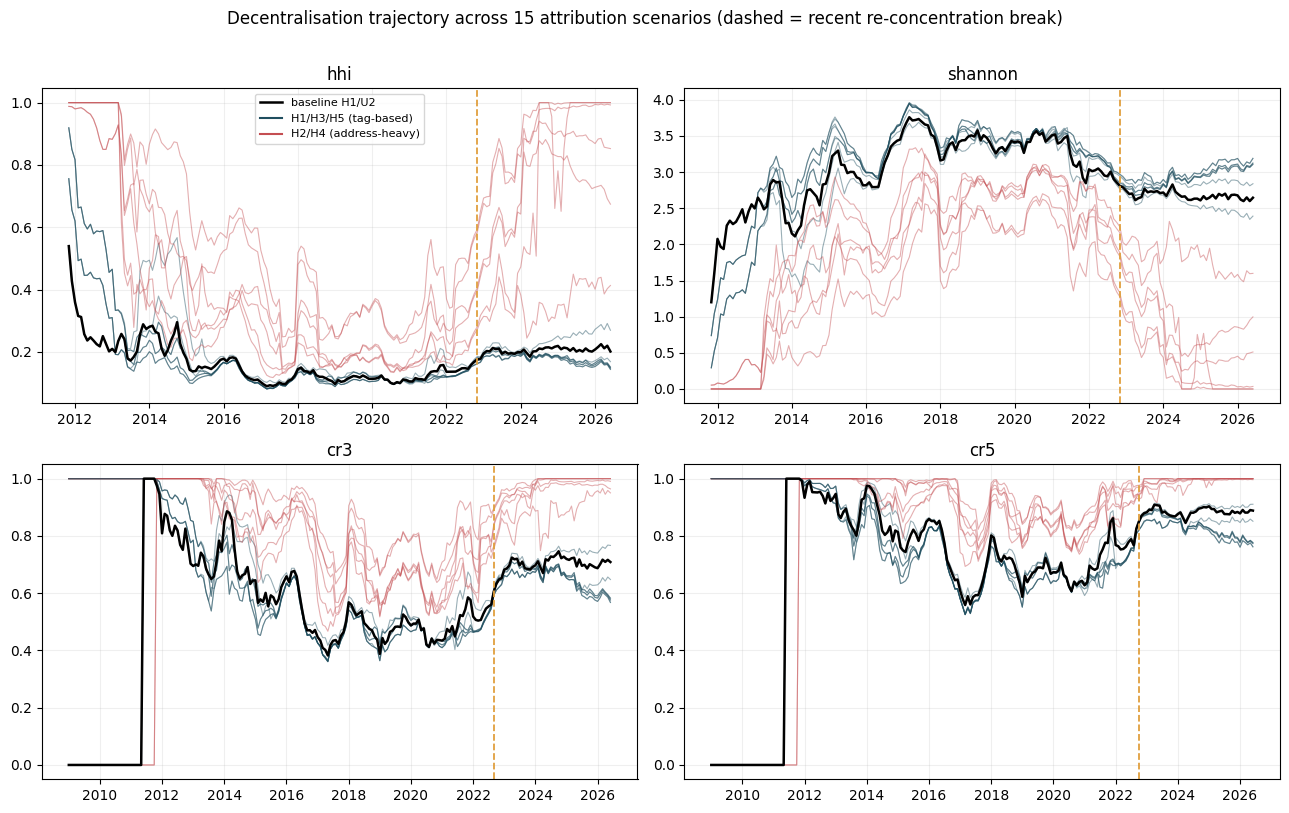

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, m in zip(axes.ravel(), METRICS):
    w = common[m]
    for col in w.columns:
        if col == ("H1", "U2"):
            continue
        red = col[0] in {"H2", "H4"}
        ax.plot(w.index, w[col].values, color="#c44e52" if red else "#1f4e5f",
                lw=0.8, alpha=0.45)
    ax.plot(w.index, w[("H1", "U2")].values, color="black", lw=1.8, label="baseline H1/U2")
    if m in recent_corrob:
        ax.axvline(pd.Timestamp(recent_corrob[m][0]), ls="--", color="#e09f3e", lw=1.3)
    ax.set_title(f"{m}"); ax.grid(alpha=0.2)
axes[0, 0].plot([], [], color="#1f4e5f", label="H1/H3/H5 (tag-based)")
axes[0, 0].plot([], [], color="#c44e52", label="H2/H4 (address-heavy)")
axes[0, 0].legend(loc="best", fontsize=8)
fig.suptitle("Decentralisation trajectory across 15 attribution scenarios "
             "(dashed = recent re-concentration break)", y=1.01)
fig.tight_layout()
os.makedirs("../figures", exist_ok=True)
fig.savefig("../figures/changepoint_robustness.png", dpi=120, bbox_inches="tight")
plt.show()

## Summary and verdict

In [8]:
rows = []
for m in METRICS:
    vals = np.array(list(corr[m].values()))
    rc = recent_corrob.get(m, ("-", None))
    rows.append({"metric": m, "median_rho": round(float(np.median(vals)), 3),
                 "min_rho": round(float(vals.min()), 3),
                 "rho>0.9": f"{int((vals > 0.9).sum())}/14",
                 "recent_break": rc[0], "recent_corroborated": f"{rc[1]}/15" if rc[1] is not None else "-"})
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
med = np.median([v for m in METRICS for v in corr[m].values()])
print(f"\nOverall median trajectory correlation across all metrics x scenarios: {med:.3f}")

 metric  median_rho  min_rho rho>0.9 recent_break recent_corroborated
    hhi       0.912    0.798    9/14      2022-11               14/15
shannon       0.918    0.866   11/14      2022-11                6/15
    cr3       0.298    0.266    2/14      2022-09               12/15
    cr5       0.309    0.264    2/14      2022-10                6/15

Overall median trajectory correlation across all metrics x scenarios: 0.872
